Red shape: (4096, 4096)
NIR shape: (4096, 4096)
NDVI Min: -0.44945255
NDVI Max: 0.9996367
NDVI Mean: 0.2645279


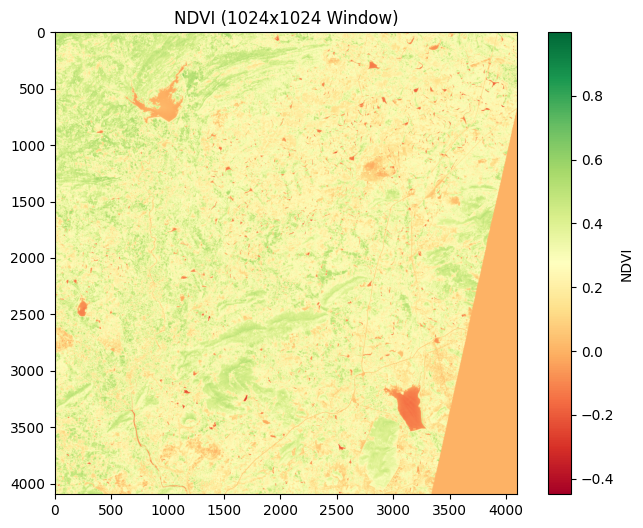

Total patches: 65536
Low variance patches (merged): 46336
Compression ratio: 0.70703125


In [1]:
import rasterio
from rasterio.windows import Window
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. FILE PATHS (EDIT THESE)
# ==============================

B04_PATH = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"

B08_PATH = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B08_10m.jp2"

# ==============================
# 2. WINDOW SETTINGS
# ==============================

WINDOW_SIZE = 4096  # Safe for 16GB RAM
window = Window(0, 0, WINDOW_SIZE, WINDOW_SIZE)

# ==============================
# 3. READ BANDS SAFELY
# ==============================

with rasterio.open(B04_PATH) as red_src:
    red = red_src.read(1, window=window).astype("float32")

with rasterio.open(B08_PATH) as nir_src:
    nir = nir_src.read(1, window=window).astype("float32")

print("Red shape:", red.shape)
print("NIR shape:", nir.shape)

# ==============================
# 4. NDVI COMPUTATION
# ==============================

np.seterr(divide='ignore', invalid='ignore')

ndvi = (nir - red) / (nir + red)
ndvi[np.isnan(ndvi)] = 0

# ==============================
# 5. PRINT STATISTICS
# ==============================

print("NDVI Min:", np.min(ndvi))
print("NDVI Max:", np.max(ndvi))
print("NDVI Mean:", np.mean(ndvi))

# ==============================
# 6. VISUALIZE RESULT
# ==============================

plt.figure(figsize=(8, 6))
plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI (1024x1024 Window)")
plt.show()
# ==============================
# 7. TOKENIZATION PARAMETERS
# ==============================

PATCH_SIZE = 16  # 16x16 tokens
H, W = ndvi.shape

num_patches_h = H // PATCH_SIZE
num_patches_w = W // PATCH_SIZE

total_patches = num_patches_h * num_patches_w

low_variance_count = 0
variance_list = []

THRESHOLD = 0.006  # You may tune this

# ==============================
# 8. PATCH VARIANCE COMPUTATION
# ==============================

for i in range(num_patches_h):
    for j in range(num_patches_w):
        patch = ndvi[
            i*PATCH_SIZE:(i+1)*PATCH_SIZE,
            j*PATCH_SIZE:(j+1)*PATCH_SIZE
        ]
        
        var = np.var(patch)
        variance_list.append(var)
        
        if var < THRESHOLD:
            low_variance_count += 1

compression_ratio = low_variance_count / total_patches

print("Total patches:", total_patches)
print("Low variance patches (merged):", low_variance_count)
print("Compression ratio:", compression_ratio)
